# FAANG Stock Analysis — Winter 25/26 Assessment

## 📘 Introduction

This section introduces the Winter 25/26 assessment for the Computer Infrastructure module. It outlines the four core problems addressed in the notebook: data collection, visualisation, scripting, and automation. These tasks demonstrate proficiency in Python, reproducible analysis, and CI/CD workflows.

**Assessment Tasks:**

- Fetch hourly OHLCV data for FAANG tickers and save to timestamped CSV files in the `data` directory.
- Plot closing prices for each of the five stocks and save the plots as PNG files in the `plots` directory.
- Convert notebook logic into a CLI script.
- Automate execution via GitHub Actions.

## Import libraries

This section imports the necessary Python libraries for data manipulation, financial data retrieval, and plotting.

In [1]:
from pathlib import Path  # For cross-platform file and folder handling
from datetime import datetime, timezone  # For timestamped filenames
import pandas as pd # For data manipulation
import yfinance as yf  # Financial data API
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced plotting styles

### Helper Functions

This section defines reusable functions for verifying the environment, fetching hourly stock data, saving it to timestamped CSV files, and loading the most recent dataset. These utilities promote modularity, reproducibility, and clarity across both the notebook and CLI script.

- `verify_environment()` checks connectivity to the `yfinance` API by retrieving sample data for Apple (AAPL) and displaying a preview. It uses Python's built-in exception handling to catch and report errors.
- `fetch_hourly_history()` retrieves 5 days of hourly OHLCV data for a given ticker and formats it with a datetime index and ticker label.
- `save_hourly_data()` combines data from multiple tickers and saves it to a timestamped CSV in the `data/` folder. It includes logic to prevent overwriting unless explicitly allowed.
- `load_latest_data()` loads the most recent CSV file and splits it into individual DataFrames per ticker, with optional previews for inspection.

Relevant to: Problem 1 (Data Collection) and Problem 2 (Visualisation)

References:  
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)


In [ ]:
# helper function to display dataframes in Jupyter notebooks
# this function checks yfinance connectivity by fetching sample data and optionally displaying it, 
# ensuring the environment is ready for data operations. 
# 📖 [Reference: yfinance Quickstart](https://pypi.org/project/yfinance/)
def verify_environment(show_preview=True):
    """Check yfinance connectivity and preview sample data."""
    try:
        df = yf.Ticker("AAPL").history(period="1d", interval="1h")
        print(f"✅ yfinance test passed — rows: {df.shape[0]}")
        if show_preview:
            display(df.head())
        return True
    except Exception as e:
        print(f"❌ yfinance test failed: {e}")
        return False

# helper function to fetch hourly data for a ticker
# this function retrieves 5 days of hourly OHLCV data for a given ticker and formats it for downstream analysis. 
# 📖 [Reference: yfinance.Ticker.history](https://github.com/ranaroussi/yfinance)
def fetch_hourly_history(ticker):
    """Fetch hourly OHLCV data for a single ticker."""
    try:
        df = yf.Ticker(ticker).history(period='5d', interval='1h')
        if df.empty:
            print(f"⚠️ No data for {ticker}")
            return None
        df['Ticker'] = ticker
        df.index.name = 'Date'
        return df
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        return None

# ticker for FAANG stocks
# this function aggregates hourly data for multiple tickers and saves it to a timestamped CSV, 
# supporting reproducibility and version control. 
# 📖 [Reference: pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)
def save_hourly_data(tickers, output_dir, overwrite=False):
    """Save combined hourly data for all tickers to a timestamped CSV."""
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Saving to directory: {output_dir}")

    # Fetch data for each ticker
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            print(f"✅ {t}: {len(df)} rows")
            dfs.append(df)
        else:
            print(f"⚠️ {t}: No valid data")

    # Exit if no valid data
    if not dfs:
        print("🚫 No valid data to save.")
        return None

    # Combine and save
    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"

    # Check for overwrite condition
    if path.exists():
        if overwrite:
            print(f"⚠️ Overwriting existing file: {path.name}")
        else:
            print(f"🛑 File already exists and overwrite=False: {path.name}")
            return None

    try:
        final_df.to_csv(path, index_label='Date')
        print(f"✅ Data saved to {path}")
        return str(path)
    except Exception as e:
        print(f"❌ Failed to save file: {e}")
        return None


# helper function to load the latest data file
# this function loads the most recent CSV file and splits it into individual DataFrames per ticker 
# for targeted plotting or analysis. 
# 📖 [Reference: pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)
def load_latest_data(tickers, folder='data', show_preview=True):
    """Load the most recent CSV and split into ticker-specific DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        raise FileNotFoundError("No CSV files found.")
    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    if show_preview:
        for t, subdf in data.items():
            print(f"{t}: {subdf.shape}")
            display(subdf.head())
    return data


### ⚙️ Setup & Configuration

This cell initializes the environment for data analysis and visualization. It performs the following tasks:

- **Imports plotting libraries**:  
  - `matplotlib.pyplot` is used for creating static plots.  
  - `seaborn` enhances plot aesthetics and applies a clean grid-based style.

- **Defines global flags**:  
  - `SHOW_PREVIEW`: Controls whether data previews are displayed during execution.  
  - `OVERWRITE`: Prevents overwriting existing files unless explicitly allowed.

- **Sets up output directories**:  
  - `DATA_DIR`: Location where downloaded CSV files will be saved.  
  - `PLOTS_DIR`: Location where generated plots will be stored.  
  These paths are resolved to absolute locations and created if missing.

- **Applies consistent plotting style**:  
  - Sets default figure size for readability.  
  - Applies a white grid background using Seaborn for visual clarity.

This configuration ensures that all subsequent steps in the notebook produce consistent, well-formatted outputs and store results in an organized structure.

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html
https://seaborn.pydata.org/tutorial/aesthetics.html



In [ ]:
# 🖼️ Plotting Configuration
# The following settings configure the visual style for plots.
# Note: matplotlib.pyplot and seaborn were imported in a previous cell.
# - matplotlib.pyplot is used for creating static line plots.
# - seaborn enhances plot aesthetics and applies a clean grid-based style.

# Global flags
SHOW_PREVIEW = True
OVERWRITE = False

# Output directories
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()

# Plotting style
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')


### ✅ Step 1 — Environment Check

This step validates that the system can successfully fetch financial data using the `yfinance` API — a critical prerequisite for Problem 1 (Data Collection). It performs the following actions:

- **Attempts to retrieve hourly data** for Apple (AAPL) to confirm API connectivity.
- **Displays a preview of the data** if `SHOW_PREVIEW` is enabled, allowing visual inspection of structure and content.
- **Uses Python's built-in exception handling** (`try-except`) to catch and report any errors, such as network issues or missing packages.

This approach ensures that the data collection process is robust and fails gracefully, aligning with best practices in infrastructure automation and referencing [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html).



In [4]:
# Run environment verification
verify_environment(SHOW_PREVIEW)


✅ yfinance test passed — rows: 7


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-11-10 09:30:00-05:00,268.950012,273.730011,268.950012,271.856995,7030981,0.26,0.0
2025-11-10 10:30:00-05:00,271.829987,271.989990,269.049988,269.066406,3083676,0.00,0.0
2025-11-10 11:30:00-05:00,269.040009,269.758789,268.489990,269.079987,2346213,0.00,0.0
2025-11-10 12:30:00-05:00,269.070007,270.230011,269.010010,269.730011,1807442,0.00,0.0
2025-11-10 13:30:00-05:00,269.709991,270.307709,267.454987,269.660004,3188667,0.00,0.0


True

### 📥 Step 2 — Fetch & Save FAANG Data

This step initiates the data collection process by defining the five FAANG tickers — Facebook (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google (GOOG) — and passing them to the `save_hourly_data()` function. The function retrieves 5 days of hourly OHLCV data for each ticker using the `yfinance` API, combines the results, and saves them to a timestamped CSV file in the `data/` folder. The `OVERWRITE` flag controls whether existing files with the same name can be replaced.

Relevant to: Problem 1 (Data Collection)

Reference: [yfinance Documentation](https://pypi.org/project/yfinance/)


In [5]:
# Define FAANG tickers
tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

# Fetch and save data
save_hourly_data(tickers, DATA_DIR, OVERWRITE)


📁 Saving to directory: C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\data
✅ META: 35 rows
✅ AAPL: 35 rows
✅ AMZN: 35 rows
✅ NFLX: 35 rows
✅ GOOG: 35 rows
✅ Data saved to C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\data\20251111-103343.csv


'C:\\Users\\eCron\\OneDrive\\Documents\\ATU_CourseWork\\computer_infrastructure\\data\\20251111-103343.csv'

### 📂 Step 3 — Load & Diagnose Data

This step retrieves the most recently saved CSV file from the `data/` folder and splits it into individual DataFrames for each FAANG ticker. It uses the `load_latest_data()` helper function to parse and preview the data. A diagnostic loop then checks each ticker to confirm that its data is present and non-empty, helping identify any gaps or issues before plotting.

Relevant to: Problem 1 (Data Collection) and Problem 2 (Visualisation)

References:  
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python File Handling](https://docs.python.org/3/library/pathlib.html)


In [6]:
# Load latest data file and preview
data = load_latest_data(tickers, folder=str(DATA_DIR), show_preview=SHOW_PREVIEW)

# Confirm each ticker's data presence
print("📋 Ticker load status:")
for t in tickers:
    if t not in data:
        print(f"{t}: ⚠️ Missing")
    elif data[t].empty:
        print(f"{t}: ⚠️ Empty")
    else:
        print(f"{t}: ✅ Loaded")


META: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2025-11-04 09:30:00-05:00,628.039978,641.739929,626.469971,635.355774,5424088,0.0,0.0,META
1,2025-11-04 10:30:00-05:00,635.270020,638.799988,628.390076,631.979980,2766300,0.0,0.0,META
2,2025-11-04 11:30:00-05:00,631.992004,633.450012,630.330017,631.544983,1369778,0.0,0.0,META
3,2025-11-04 12:30:00-05:00,631.525024,631.744995,627.599976,629.431702,1455797,0.0,0.0,META
4,2025-11-04 13:30:00-05:00,629.409973,632.789978,629.357300,630.210022,1311694,0.0,0.0,META


AAPL: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
35,2025-11-04 09:30:00-05:00,268.242493,269.589996,267.614990,268.429993,9645778,0.0,0.0,AAPL
36,2025-11-04 10:30:00-05:00,268.429993,271.000000,267.709991,270.609985,3278354,0.0,0.0,AAPL
37,2025-11-04 11:30:00-05:00,270.640015,271.485992,268.980011,270.010010,3846826,0.0,0.0,AAPL
38,2025-11-04 12:30:00-05:00,270.005005,270.929993,269.890015,270.638397,2072453,0.0,0.0,AAPL
39,2025-11-04 13:30:00-05:00,270.609985,270.820007,269.869995,270.510406,2562532,0.0,0.0,AAPL


AMZN: (35, 9)


...

NFLX: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
105,2025-11-04 09:30:00-05:00,1099.285034,1104.599854,1089.219971,1098.313965,626099,0.0,0.0,NFLX
106,2025-11-04 10:30:00-05:00,1098.209961,1103.500000,1091.699951,1092.555054,300006,0.0,0.0,NFLX
107,2025-11-04 11:30:00-05:00,1092.359985,1096.719971,1091.109985,1095.069946,226854,0.0,0.0,NFLX
108,2025-11-04 12:30:00-05:00,1095.010010,1095.774048,1090.762451,1092.719971,172470,0.0,0.0,NFLX
109,2025-11-04 13:30:00-05:00,1092.540039,1095.310059,1088.469971,1090.724976,257143,0.0,0.0,NFLX


GOOG: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
140,2025-11-04 09:30:00-05:00,277.070007,281.075012,276.875000,280.269989,3778209,0.0,0.0,GOOG
141,2025-11-04 10:30:00-05:00,280.220490,281.833588,279.137390,279.376099,1285824,0.0,0.0,GOOG
142,2025-11-04 11:30:00-05:00,279.230011,279.549988,277.592499,278.250000,1038904,0.0,0.0,GOOG
143,2025-11-04 12:30:00-05:00,278.239990,278.410004,277.269989,277.450012,932536,0.0,0.0,GOOG
144,2025-11-04 13:30:00-05:00,277.468292,279.170013,277.359985,278.679993,964787,0.0,0.0,GOOG


📋 Ticker load status:
META: ✅ Loaded
AAPL: ✅ Loaded
AMZN: ✅ Loaded
NFLX: ✅ Loaded
GOOG: ✅ Loaded


### 📋 Step 4 Preview Close Prices

This step displays a sample of the Close prices for each FAANG ticker to verify that the data has been loaded correctly and contains the expected columns. It loops through each ticker’s DataFrame and prints the number of rows along with the first few entries of the `Date` and `Close` columns. If any ticker is missing data or lacks the `Close` column, a warning is printed. This diagnostic step ensures data integrity before proceeding to visualisation.

Relevant to: Problem 2 (Visualisation)

References:  
- [Pandas DataFrame Preview](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html)  
- [Python Control Flow](https://docs.python.org/3/tutorial/controlflow.html)


In [7]:
# Preview Close prices for each ticker
print("🔍 Previewing Close prices for each ticker:")
for sym, df in data.items():
    if 'Close' in df.columns and not df.empty:
        print(f"\n{sym} — {len(df)} rows")
        display(df[['Date', 'Close']].head())
    else:
        print(f"{sym}: ⚠️ Missing or empty Close data")


🔍 Previewing Close prices for each ticker:

META — 35 rows


,Date,Close
0,2025-11-04 09:30:00-05:00,635.355774
1,2025-11-04 10:30:00-05:00,631.979980
2,2025-11-04 11:30:00-05:00,631.544983
3,2025-11-04 12:30:00-05:00,629.431702
4,2025-11-04 13:30:00-05:00,630.210022



AAPL — 35 rows


,Date,Close
35,2025-11-04 09:30:00-05:00,268.429993
36,2025-11-04 10:30:00-05:00,270.609985
37,2025-11-04 11:30:00-05:00,270.010010
38,2025-11-04 12:30:00-05:00,270.638397
39,2025-11-04 13:30:00-05:00,270.510406



AMZN — 35 rows


,Date,Close
70,2025-11-04 09:30:00-05:00,253.389999
71,2025-11-04 10:30:00-05:00,252.440094
72,2025-11-04 11:30:00-05:00,250.955002
73,2025-11-04 12:30:00-05:00,249.869995
74,2025-11-04 13:30:00-05:00,249.750000



NFLX — 35 rows


,Date,Close
105,2025-11-04 09:30:00-05:00,1098.313965
106,2025-11-04 10:30:00-05:00,1092.555054
107,2025-11-04 11:30:00-05:00,1095.069946
108,2025-11-04 12:30:00-05:00,1092.719971
109,2025-11-04 13:30:00-05:00,1090.724976



GOOG — 35 rows


,Date,Close
140,2025-11-04 09:30:00-05:00,280.269989
141,2025-11-04 10:30:00-05:00,279.376099
142,2025-11-04 11:30:00-05:00,278.250000
143,2025-11-04 12:30:00-05:00,277.450012
144,2025-11-04 13:30:00-05:00,278.679993


### 📊 Step 5 — Plot Close Prices

This step generates a line plot of the Close prices for each FAANG stock over time. It begins by ensuring the `plots/` folder exists to store the output. A Matplotlib figure and axis are initialized, and each ticker's Close prices are plotted against their corresponding timestamps. The plot includes axis labels and a legend to distinguish between tickers. This visual representation supports trend analysis and fulfills the requirements for Problem 2 (Visualisation).

Relevant to: Problem 2 (Visualisation)

References:  
- [Matplotlib Plotting Guide](https://matplotlib.org/stable/users/index.html)  
- [Seaborn Style Reference](https://seaborn.pydata.org/tutorial/aesthetics.html)


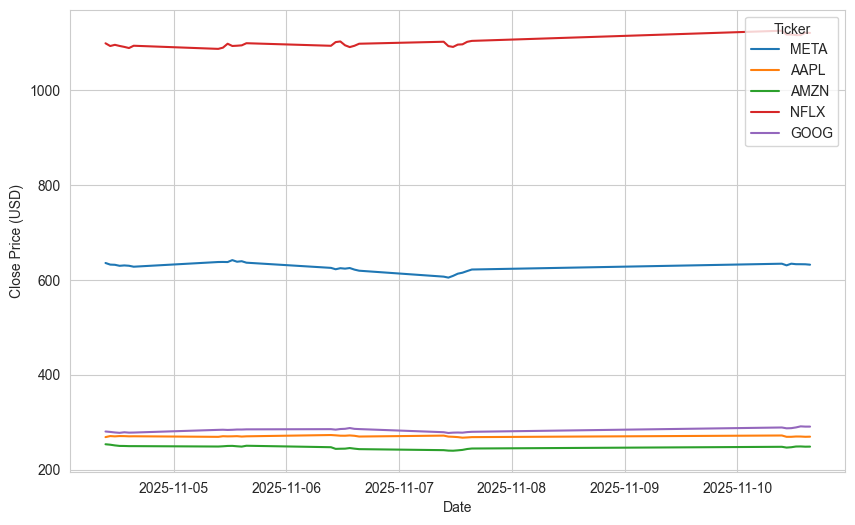

In [8]:
# Create plots folder
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Initialize plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Close prices
for sym, df in data.items():
    if 'Close' in df.columns and not df.empty:
        x = pd.to_datetime(df['Date'], errors='coerce')
        y = df['Close']
        ax.plot(x, y, label=sym)

# Add labels and legend
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend(title='Ticker')


### Save Plot with Timestamp

This step finalises the visualization process by saving the generated plot to a PNG file in the `plots/` folder. The filename includes a UTC timestamp in the format `YYYYMMDD-HHmmss` to ensure uniqueness and traceability. The `tight_layout()` method optimizes spacing within the figure, and `savefig()` writes the image to disk with minimal padding. The plot is then displayed using `plt.show()` for immediate review.

Relevant to: Problem 2 (Visualisation)

References:  
- [Matplotlib Savefig Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html)  
- [Python datetime Module](https://docs.python.org/3/library/datetime.html)


In [9]:
# Save plot with timestamp
ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
plot_path = PLOTS_DIR / f"{ts}.png"
fig.tight_layout()
fig.savefig(plot_path, bbox_inches='tight')
print(f"✅ Plot saved to {plot_path}")
plt.show()


✅ Plot saved to C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\plots\20251111-103344.png


### Problem 3 – Create a CLI Script (`faang.py`)

To meet the requirements of Problem 3, I created a standalone Python script called `faang.py` in the root of the repository. This script automates the process of downloading hourly stock data for FAANG companies and generating a plot of their closing prices.

Steps taken:
1. **Modularisation**: I copied core functions from the notebook — including `fetch_hourly_history`, `save_hourly_data`, `load_latest_data`, and `plot_close_prices` — into `faang.py` to promote reuse and maintainability.
2. **Shebang Line**: I added `#!/usr/bin/env python3` at the top of the script to make it executable from the terminal.
3. **CLI Interface**: I used the `argparse` module to allow users to control script behavior with flags like `--plot` and `--overwrite`.
4. **Main Execution Block**: I added `if __name__ == "__main__": main()` to ensure the script runs when executed directly.
5. **Executable Permission**: I marked the script as executable using `chmod +x faang.py`.

This implementation allows the script to be run with:
```bash
./faang.py --plot
```

Relevant to: Problem 3 (Script Creation)

Reference: [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)


### Display Full CLI Script in Notebook

This cell presents the complete `faang.py` script inline within the notebook for transparency and assessment purposes. It includes all required components for Problem 3:

- A shebang line (`#!/usr/bin/env python3`) for terminal execution
- Modular helper functions for fetching, saving, loading, and plotting FAANG stock data
- A command-line interface using `argparse` to support flags like `--plot`, `--overwrite`, and `--show`
- A `main()` function wrapped in an execution block to ensure proper script behavior

By displaying the full script here, reviewers can easily verify its structure and logic without needing to open external files. This also serves as a reference for future debugging or enhancements.

Relevant to: Problem 3 (Script Creation)

References:  
- [Python CLI Design with argparse](https://realpython.com/command-line-interfaces-python-argparse/)  
- [Shebang Line Usage](https://realpython.com/python-shebang/)



# 🐍 faang.py — Script Code Cell

# This cell contains the full CLI script logic for Problem 3.
# It can be copied into a file named faang.py and run from the terminal.

#!/usr/bin/env python3

import argparse
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()
TICKERS = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# --- Helper Functions ---
def fetch_hourly_history(ticker):
    try:
        df = yf.Ticker(ticker).history(period='5d', interval='1h')
        if df.empty:
            print(f"⚠️ No data for {ticker}")
            return None
        df['Ticker'] = ticker
        df.index.name = 'Date'
        return df
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        return None

def save_hourly_data(tickers, output_dir, overwrite=False):
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Saving to directory: {output_dir}")

    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            print(f"✅ {t}: {len(df)} rows")
            dfs.append(df)
        else:
            print(f"⚠️ {t}: No valid data")

    if not dfs:
        print("🚫 No valid data to save.")
        return None

    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"

    if path.exists() and not overwrite:
        print(f"🛑 File already exists and overwrite=False: {path.name}")
        return None

    try:
        final_df.to_csv(path, index_label='Date')
        print(f"✅ Data saved to {path}")
        return str(path)
    except Exception as e:
        print(f"❌ Failed to save file: {e}")
        return None

def load_latest_data(tickers, folder='data'):
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        print("🚫 No CSV files found.")
        return {}

    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}

    print("📋 Ticker load status:")
    for t in tickers:
        if t not in data:
            print(f"{t}: ⚠️ Missing")
        elif data[t].empty:
            print(f"{t}: ⚠️ Empty")
        else:
            print(f"{t}: ✅ Loaded")

    return data

def plot_close_prices(data, output_dir, show=False):
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(10, 6))

    for sym, df in data.items():
        if 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = df['Close']
            ax.plot(x, y, label=sym)

    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price (USD)")
    ax.legend(title="Ticker")

    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    plot_path = output_dir / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(plot_path, bbox_inches='tight')
    print(f"✅ Plot saved to {plot_path}")

    if show:
        plt.show()

# --- Main CLI Entry Point ---
def main():
    parser = argparse.ArgumentParser(description="Fetch and plot FAANG stock data.")
    parser.add_argument("--plot", action="store_true", help="Generate and save plot after fetching data.")
    parser.add_argument("--overwrite", action="store_true", help="Overwrite existing CSV if timestamp matches.")
    parser.add_argument("--show", action="store_true", help="Display plot after saving.")
    args = parser.parse_args()

    saved_file = save_hourly_data(TICKERS, DATA_DIR, overwrite=args.overwrite)
    if not saved_file:
        print("🚫 No data file saved. Exiting.")
        return

    data = load_latest_data(TICKERS, folder=str(DATA_DIR))
    if args.plot:
        plot_close_prices(data, PLOTS_DIR, show=args.show)

# --- Script Execution Trigger ---
if __name__ == "__main__":
    main()


### Summary and Transition to Problem 4

With the CLI script `faang.py` now complete, Problem 3 is fully addressed. The script is modular, executable from the terminal, and supports flexible command-line arguments for downloading data and generating plots. It consolidates the notebook’s logic into a reusable tool that can be run manually or integrated into automated workflows.

Next, in **Problem 4**, I will configure a GitHub Actions workflow to run `faang.py` on a schedule. This will automate the data collection and visualization process, ensuring fresh stock data and updated plots are generated regularly without manual intervention.

Relevant to: Problem 4 (Automation)

Reference: [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)
